# Qno. 3 Build a spam filter using SVM. A spam filter classify an email to be Ham or Spam, using the content of an email as features.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
file_path = '../schoolDataset/emails.csv'  # Update with the actual path
emails_df = pd.read_csv(file_path)

In [12]:
emails_df.info()
emails_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [13]:
emails_df = emails_df.drop(columns=["Email No."])
missing_values = emails_df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")

Total missing values: 0


In [14]:
X = emails_df.drop(columns=["Prediction"])  # Feature set
y = emails_df["Prediction"]  # Target variable

In [17]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [18]:
svm_classifier = SVC(kernel='linear', random_state=1)

In [19]:
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=1)

In [20]:
y_pred = svm_classifier.predict(X_test)

In [21]:
# Generate and display the classification report
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:\n", classification_rep)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96      1098
           1       0.91      0.92      0.92       454

    accuracy                           0.95      1552
   macro avg       0.94      0.94      0.94      1552
weighted avg       0.95      0.95      0.95      1552



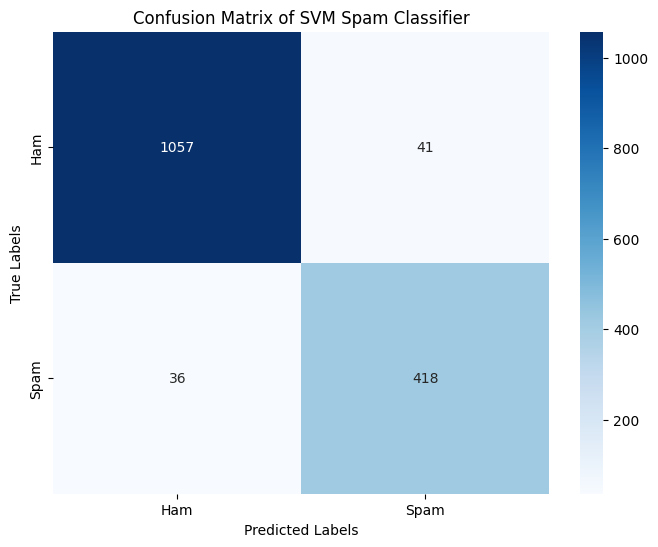

In [23]:
# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix of SVM Spam Classifier")
plt.show()

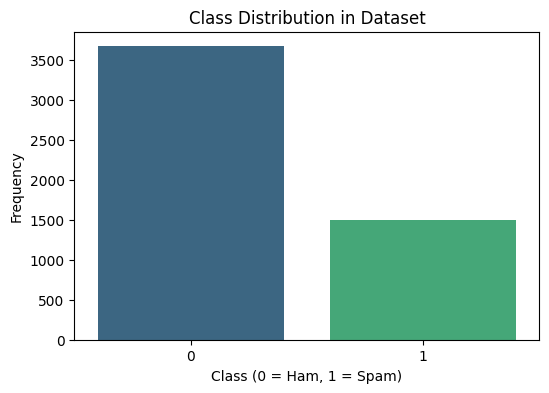

In [25]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y, hue=y, palette="viridis", legend=False)
plt.title("Class Distribution in Dataset")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Frequency")
plt.show()
